# Part 1
import necessary packages first
import the file
then format the data into matrices/vectors
Check the shape of the data to verify


In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt

with open("Boston_house_prices_dataset.csv", newline="") as file:
    reader = csv.DictReader(file)
    columns = reader.fieldnames
    rows = [
        {name: float(value) for name, value in row.items()}
        for row in reader
    ]
feature_names = columns[:-1]
target_name = columns[-1]  # MEDV

X = np.array([[row[name] for name in columns[:-1]] for row in rows])
Y = np.array([[row[columns[-1]]] for row in rows])

print(f"The shape of X is {X.shape}")
print(f"The shape of Y is {Y.shape}")

The shape of X is (506, 13)
The shape of Y is (506, 1)


In [2]:
# for name, count in zip(feature_names, np.isnan(X).sum(axis=0)):
#     print(f"  {name}: {count}")
# 
# if np.isnan(Y).any():
#     raise ValueError("Training targets contain missing values")
# 
# if np.isnan(X).all(axis=0).any():
#     raise ValueError("A feature column is entirely missing in the training set")

Now split data into training and testing set

In [3]:
split = int(0.8 * len(rows)) # 80%

X_train = X[:split, :]
Y_train = Y[:split, :]

X_test = X[split:, :]
Y_test = Y[split:, :]

print(f"The shape of X_train is {X_train.shape} and X_test is {X_test.shape}")

The shape of X_train is (404, 13) and X_test is (102, 13)


In [4]:
def getWeightsInv(xx, yy):
    return np.linalg.solve(xx.T @ xx, xx.T @ yy)

def getWeightsPInv(xx, yy):
    a = np.column_stack((xx, np.ones(len(xx))))
    a_inv = np.linalg.pinv(a)
    return a_inv @ yy # get paramters (W) back by matrix multiplication of A+ and Y
    

methods for getting weights
1) using normal equation 
2) using pseudo-inverse $A^+ = (A^T A)^{−1} A^T$



In [5]:
def mse(actual, predicted, w):
    return np.mean((actual.ravel() - (predicted @ w).ravel()) ** 2)

added mean square error function for part 5

# Part 2
plot LSTAT DIS and MEDV

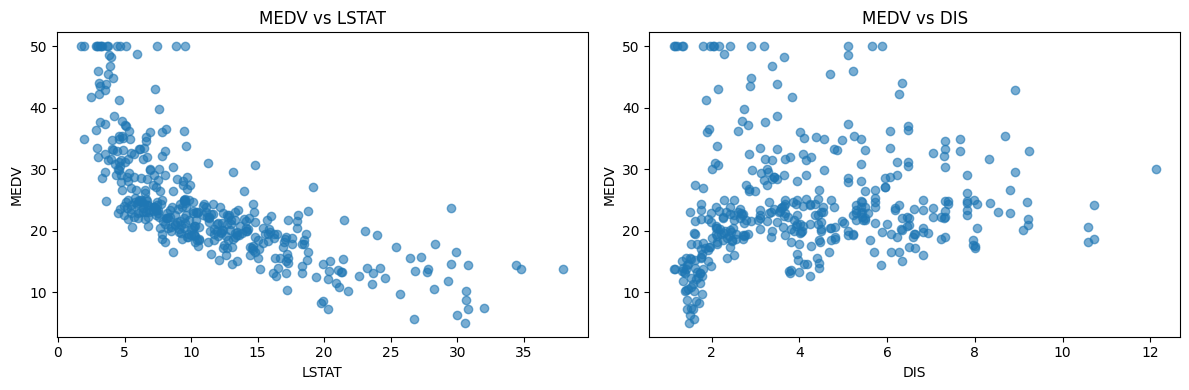

In [6]:
lstat = X_train[:, feature_names.index("LSTAT")]
dis = X_train[:, feature_names.index("DIS")]
medv = Y_train.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(lstat, medv, alpha=0.6)
axes[0].set(xlabel="LSTAT", ylabel="MEDV", title="MEDV vs LSTAT")

axes[1].scatter(dis, medv, alpha=0.6)
axes[1].set(xlabel="DIS", ylabel="MEDV", title="MEDV vs DIS")

plt.tight_layout()
plt.show()

I can see a clear downward, curved relationship between LSTAT and MEDV: higher LSTAT tends to come with lower MEDV. The relationship with DIS is generally weaker and more scattered.

# Part 3
Find the optimal regression parameters (weights) using the closed form of the linear regression for the Least Square Error
$Y = A W$ where $A = \begin{bmatrix} X & 1 \end{bmatrix}$
$W=A^+ Y$

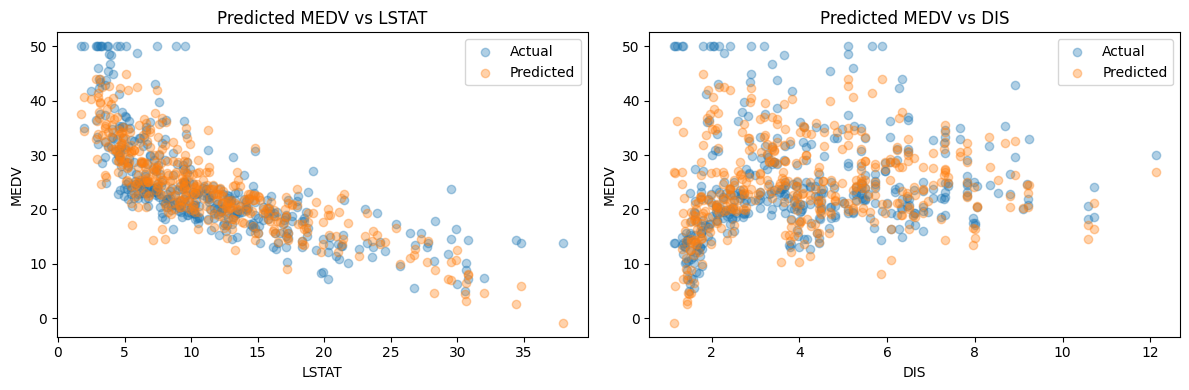

MSE is 22.77837952180079


In [7]:
A_train = np.column_stack((X_train, np.ones(len(X_train))))
W = getWeightsPInv(X_train, Y_train) # get paramters (W) back by matrix multiplication of A+ and Y

Y_pred_train = (A_train @ W).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name in zip(axes, ("LSTAT", "DIS")):
    values = X_train[:, feature_names.index(name)]
    ax.scatter(values, Y_train.ravel(), alpha=0.35, label="Actual")
    ax.scatter(values, Y_pred_train, alpha=0.35, label="Predicted")
    ax.set(xlabel=name, ylabel="MEDV", title=f"Predicted MEDV vs {name}")
    ax.legend()

plt.tight_layout()
plt.show()

mse_lin = mse(Y_train, A_train, W)

print(f"MSE is {mse_lin}")

It looks like the predicted MEDV generally decrease as LSTAT increases (similar predicted and actual representation). The pattern against DIS is again less clear. My guess as to why this is, is because the other 12 columns also play a role in computing the output, which isnt represented here. This would also explain why plotting the predictions against just one feature produces a cloud of points rather than necessarily a single line.

# Part 4


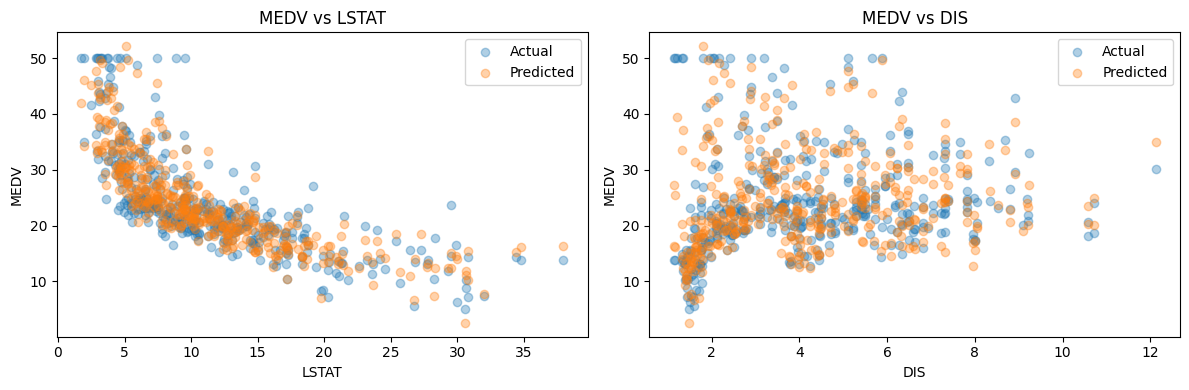

MSE is 14.485636586720956


In [9]:
X_train_quad = np.column_stack((X_train, X_train**2)) #combine the columns, and make the second set squared
A_train_quad = np.column_stack((X_train_quad,np.ones(len(X_train_quad))))
W_quad = getWeightsPInv(X_train_quad, Y_train)

Y_pred_train = (A_train_quad @ W_quad).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name in zip(axes, ("LSTAT", "DIS")):
    values = X_train[:, feature_names.index(name)]

    ax.scatter(values, Y_train.ravel(), alpha=0.35, label="Actual")
    ax.scatter(values, Y_pred_train, alpha=0.35, label="Predicted")
    ax.set(xlabel=name, ylabel="MEDV", title=f"MEDV vs {name}")
    ax.legend()

fig.tight_layout()
plt.show()

mse_quad = mse(Y_train, A_train_quad, W_quad)

print(f"MSE is {mse_quad}")

# Part 5
The MSE function was added to part one and used belows the plots in parts 3 and 4.

In [11]:
print(f"The MSE for part 3 is {mse_lin} and the MSE for part 4 is {mse_quad}")

# get test MSE for part 3
A_test = np.column_stack((X_test, np.ones(len(X_test))))
W_test = getWeightsPInv(X_test, Y_test)
Y_pred_test = (A_test @ W_test).ravel()

# get test MSE for part 4
X_test_quad = np.column_stack((X_test, X_test**2))
A_test_quad = np.column_stack((X_test_quad,np.ones(len(X_test_quad))))
W_test_quad = getWeightsPInv(X_test_quad, Y_test)
Y_pred_test_quad = (A_test_quad @ W_test_quad).ravel()

mse_test_lin =   mse(Y_test, A_test, W_test)
mse_test_quad =  mse(Y_test, A_test_quad, W_test_quad)

print(f"The MSE (test set) for part 3 is {mse_test_lin} and the MSE (test set) for part 4 is {mse_test_quad}")

The MSE for part 3 is 22.77837952180079 and the MSE for part 4 is 14.485636586720956
The MSE (test set) for part 3 is 8.834063005820594 and the MSE (test set) for part 4 is 7.2594771043539135


You can tell from comparing the MSE values that (reduced between part 3 and part 4) that adding the extra columns squared helped reduce the error.